In [3]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)
from scipy import stats
print("All libraries imported successfully")

All libraries imported successfully


In [5]:
# load data set
df = pd.read_csv("oil_sales_assignment_dataset.csv")

df.head(5)

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,1226.10,20.1,61.0
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,996.30,12.3,81.0


In [8]:
df.tail(5)

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
1995,TABUK,HM No 99317 GS-CENTER-TABUK MAIN RD TABUK,NAJDI CONSUMER,LARA,COCONUT,0.5L,LARA COCONUT 0.5L PREMIUM,31-40,2024,11,74.4,2.4,31.0
1996,AL AHSA,HM No 85390 GS-CENTER-AL AHSA MAIN RD AL AHSA,BLUE OASIS CO,LARA,SUNFLOWER,3L,LARA SUNFLOWER 3L,31-40,2022,5,20.0,0.5,40.0
1997,AL KHARJ,HM No 90740 GS-CENTER-AL KHARJ MAIN RD AL K...,NOVA FOODS,NOUR,SUNFLOWER,2.9L,NOUR SUNFLOWER 2.9L,91-100,2023,8,527.8,5.8,91.0
1998,RIYADH,HM No 52893 GS-CENTER-RIYADH MAIN RD RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,NAJMA CORN 0.75L ECO,61-70,2024,6,305.0,5.0,61.0
1999,JEDDAH,HM No 73689 GS-CENTER-JEDDAH MAIN RD JEDDAH,NAJDI CONSUMER,BAYTNA,COCONUT,1.8L,BAYTNA COCONUT 1.8L ECO,101+,2022,4,181.8,1.8,101.0


In [10]:
df.shape

(2000, 13)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           2000 non-null   object 
 1   store_name     2000 non-null   object 
 2   manufacturer   2000 non-null   object 
 3   brand          2000 non-null   object 
 4   class          2000 non-null   object 
 5   size           2000 non-null   object 
 6   sku            2000 non-null   object 
 7   price_bracket  2000 non-null   object 
 8   year           2000 non-null   int64  
 9   month          2000 non-null   int64  
 10  value_sales    2000 non-null   float64
 11  volume_sales   2000 non-null   float64
 12  average_price  2000 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 203.3+ KB


In [15]:
df.isnull().sum()

city             0
store_name       0
manufacturer     0
brand            0
class            0
size             0
sku              0
price_bracket    0
year             0
month            0
value_sales      0
volume_sales     0
average_price    0
dtype: int64

In [16]:
df.describe()

,year,month,value_sales,volume_sales,average_price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022.990500,6.639500,614.839355,9.972100,60.990230
std,0.820211,3.468942,750.794991,9.862369,29.457029
min,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,2024.000000,10.000000,794.100000,13.800000,81.000000
max,2024.000000,12.000000,6253.200000,81.700000,140.000000


In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


In [21]:
#Encode categorical columns

df['city_encoded'] = le.fit_transform(df['city'])
df['store_name_encoded'] = le.fit_transform(df['store_name'])
df['manufacturer_encoded'] = le.fit_transform(df['manufacturer'])
df['brand_encoded'] = le.fit_transform(df['brand'])
df['class_encoded'] = le.fit_transform(df['class'])
df['size_encoded'] = le.fit_transform(df['size'])
df['sku_encoded'] = le.fit_transform(df['sku'])
df['price_bracket_encoded'] = le.fit_transform(df['price_bracket'])
df.head()

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,...,volume_sales,average_price,city_encoded,store_name_encoded,manufacturer_encoded,brand_encoded,class_encoded,size_encoded,sku_encoded,price_bracket_encoded
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,...,30.1,27.6,1,302,5,3,1,3,537,2
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,...,9.1,41.0,2,237,6,4,0,1,648,4
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,...,1.7,101.0,8,1487,0,0,3,3,93,0
3,DAMMAM,HM No 95753 GS-CENTER-DAMMAM MAIN RD DAMMAM,PALM & GRAIN GROUP,NOUR,CORN,0.6L,NOUR CORN 0.6L TWIN PACK,61-70,2022,2,...,20.1,61.0,3,1832,6,5,2,2,864,6
4,JAZAN,HM No 56338 GS-CENTER-JAZAN MAIN RD JAZAN,DESERT SUN CO,NOUR,VEGETABLE,1L,NOUR VEGETABLE 1L,81-90,2024,2,...,12.3,81.0,5,258,3,5,4,7,944,8


In [27]:
# Independent variable (X)
X = df[['average_price']]
# Target variable (y)
y = df['value_sales']

In [28]:
# split the data set
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [30]:
# train the linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
intercept = model.intercept_
coefficient = model.coef_[0]
print(f"Intercept : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")


Intercept : -27.28
Coefficient : 10.51


In [35]:
#make pridiction
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [46]:
# evaluate the model
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)
print("train_rmse =",train_rmse)
print("test_rmse =",test_rmse)
print("train_r2 =",train_r2)
print("test_r2 =",test_r2)


train_rmse = 687.8606680243196
test_rmse = 674.0336191200048
train_r2 = 0.1734909078761384
test_r2 = 0.13802212065425412


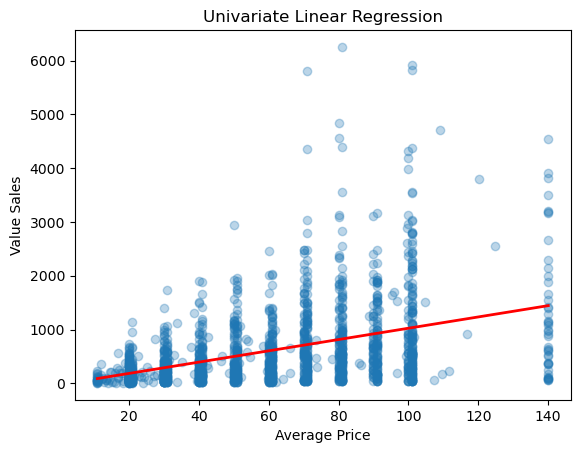

In [54]:
plt.scatter(X_train, y_train, alpha=0.3, label= 'Actual Data')
X_sorted = X_train.sort_values("average_price")
y_sorted = model.predict(X_sorted)
plt.plot(X_sorted,y_sorted,color="red",linewidth=2, label = "Regression Line")
plt.xlabel("Average Price")
plt.ylabel("Value Sales")
plt.title("Univariate Linear Regression")
plt.show()